In [ ]:
#Section 1: Wrapper Layer (bitcoin_utils.py)

In [1]:
import os
import pandas as pd
from bitcoin_utils import (
    fetch_price,
    record_price,
    record_live_prices,
    preprocess,
    plot_data
)


In [3]:
record_price()
print("✅ Recorded one BTC price.")


✅ Recorded one BTC price.


In [5]:
record_live_prices(duration_seconds=120, interval_seconds=10)


Recording Bitcoin prices every 10 seconds for 120 seconds...

✔️ Recorded price 1/12
✔️ Recorded price 2/12
✔️ Recorded price 3/12
✔️ Recorded price 4/12
✔️ Recorded price 5/12
✔️ Recorded price 6/12
✔️ Recorded price 7/12
✔️ Recorded price 8/12
Error fetching price: 'bitcoin'
Price not available.
✔️ Recorded price 9/12
Error fetching price: 'bitcoin'
Price not available.
✔️ Recorded price 10/12
Error fetching price: 'bitcoin'
Price not available.
✔️ Recorded price 11/12
Error fetching price: 'bitcoin'
Price not available.
✔️ Recorded price 12/12

✅ Finished recording.


In [7]:
df_raw = pd.read_csv("data/bitcoin_prices.csv")
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw.tail(10)


,timestamp,price
31,NaT,103187
32,NaT,103211
33,NaT,103211
34,NaT,103211
35,NaT,103211
36,NaT,103211
37,NaT,103211
38,NaT,103211
39,NaT,103211
40,NaT,103211


In [9]:
df_clean = preprocess()
df_clean.tail(10)


,timestamp,price,price_diff,rolling_avg
1,2025-05-17 23:07:23+00:00,103059,0.0,NaN
2,2025-05-17 23:07:28+00:00,103059,0.0,NaN
3,2025-05-17 23:07:33+00:00,103059,0.0,NaN
4,2025-05-17 23:07:38+00:00,103055,-4.0,103058.2
5,2025-05-17 23:08:46+00:00,103055,0.0,103057.4
6,2025-05-17 23:08:56+00:00,103055,0.0,103056.6
7,2025-05-17 23:09:06+00:00,103055,0.0,103055.8
8,2025-05-17 23:09:16+00:00,103055,0.0,103055.0
9,2025-05-17 23:09:26+00:00,103055,0.0,103055.0
10,2025-05-17 23:09:36+00:00,103047,-8.0,103053.4


In [11]:
from IPython.display import display

df_last12 = df_clean.tail(12).copy()
df_last12['DateTime'] = pd.to_datetime(df_last12['timestamp']).dt.strftime("%Y-%m-%d %H:%M:%S")
df_last12['Price'] = df_last12['price'].apply(lambda p: f"${p:,.2f}")
display(df_last12[['DateTime', 'Price']])


,DateTime,Price
0,2025-05-17 23:07:18,"$103,059.00"
1,2025-05-17 23:07:23,"$103,059.00"
2,2025-05-17 23:07:28,"$103,059.00"
3,2025-05-17 23:07:33,"$103,059.00"
4,2025-05-17 23:07:38,"$103,055.00"
5,2025-05-17 23:08:46,"$103,055.00"
6,2025-05-17 23:08:56,"$103,055.00"
7,2025-05-17 23:09:06,"$103,055.00"
8,2025-05-17 23:09:16,"$103,055.00"
9,2025-05-17 23:09:26,"$103,055.00"


In [13]:
plot_data(df_clean)


✅ Plot saved to Output/bitcoin_price_plot.png


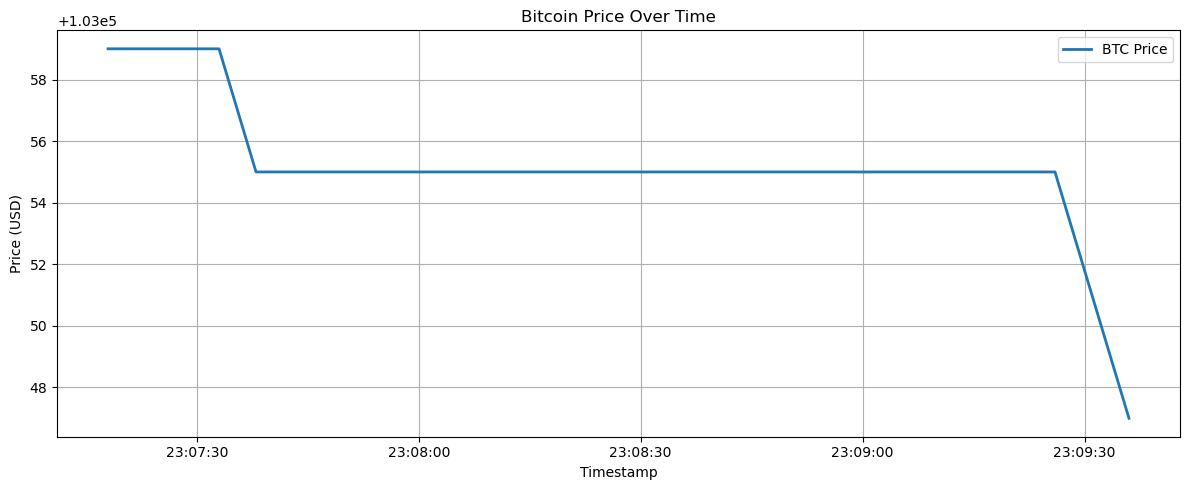

In [15]:
#1. Bitcoin Price Over Time (Line Plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df_clean['timestamp']), df_clean['price'], label='BTC Price', linewidth=2)
plt.title("Bitcoin Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


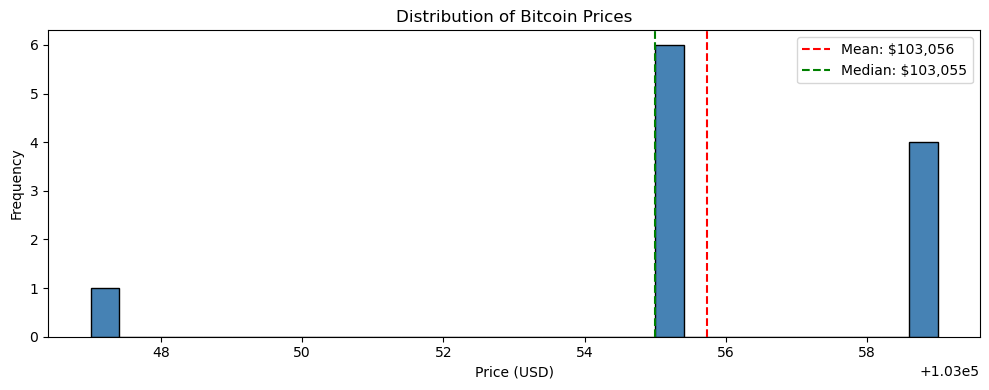

In [17]:
#2. Histogram of Prices with Mean and Median
plt.figure(figsize=(10, 4))
plt.hist(df_clean['price'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df_clean['price'].mean():,.0f}")
plt.axvline(df_clean['price'].median(), color='green', linestyle='--', label=f"Median: ${df_clean['price'].median():,.0f}")
plt.title("Distribution of Bitcoin Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


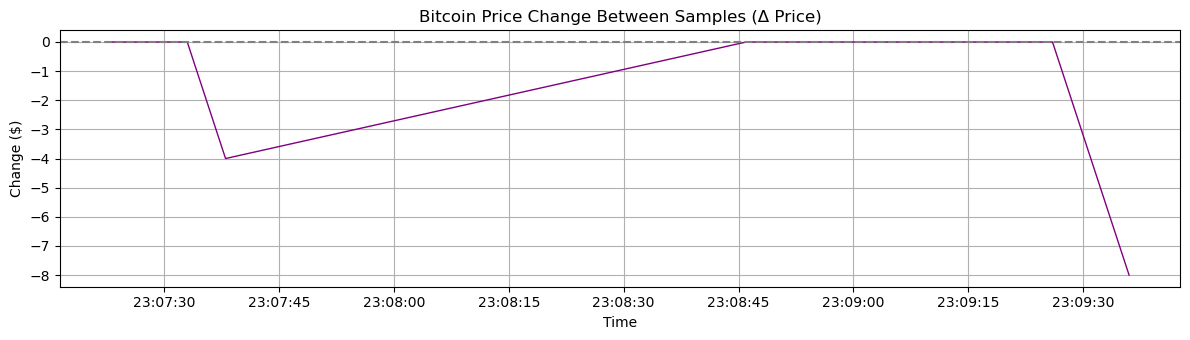

In [21]:
# 3. Price Difference (Delta) Over Time
plt.figure(figsize=(12, 3.5))
plt.plot(pd.to_datetime(df_clean['timestamp']), df_clean['price_diff'], color='purple', linewidth=1)
plt.axhline(0, linestyle='--', color='gray')
plt.title("Bitcoin Price Change Between Samples (Δ Price)")
plt.xlabel("Time")
plt.ylabel("Change ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


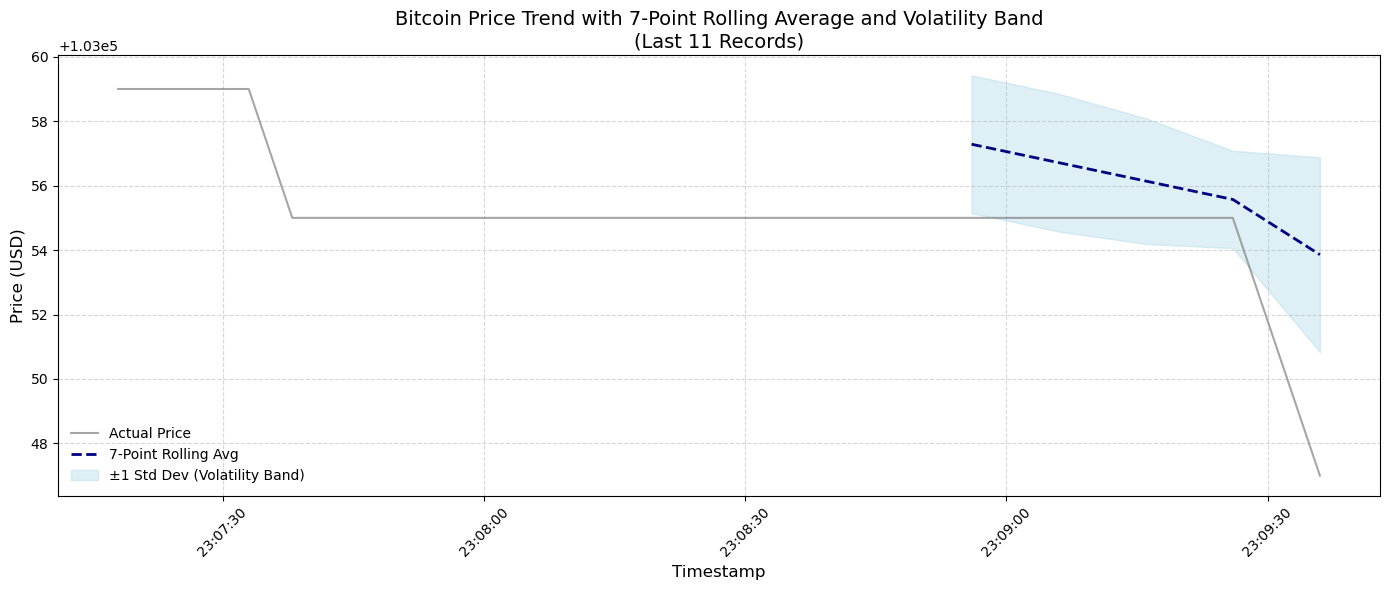

In [41]:
#4. Rolling Average with Volatility Band
import matplotlib.pyplot as plt

# Calculate rolling metrics (7-point)
df_clean['rolling_avg_7'] = df_clean['price'].rolling(window=7).mean()
df_clean['rolling_std_7'] = df_clean['price'].rolling(window=7).std()

# Parse timestamps only once for plotting
timestamps = pd.to_datetime(df_clean['timestamp'])

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(timestamps, df_clean['price'], label='Actual Price', color='gray', linewidth=1.5, alpha=0.7)
plt.plot(timestamps, df_clean['rolling_avg_7'], label='7-Point Rolling Avg', linestyle='--', color='navy', linewidth=2)

# Volatility shading
plt.fill_between(
    timestamps,
    df_clean['rolling_avg_7'] - df_clean['rolling_std_7'],
    df_clean['rolling_avg_7'] + df_clean['rolling_std_7'],
    color='lightblue',
    alpha=0.4,
    label='±1 Std Dev (Volatility Band)'
)

# Labels and formatting
plt.title(f"Bitcoin Price Trend with 7-Point Rolling Average and Volatility Band\n(Last {len(df_clean)} Records)", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()


In [23]:
# Select relevant numeric columns
summary_stats = df_clean[['price', 'price_diff', 'rolling_avg']].describe()

# Round for better readability
summary_stats = summary_stats.round(2)

# Display nicely
print("📈 Summary Statistics for Bitcoin Price Data:")
display(summary_stats)


📈 Summary Statistics for Bitcoin Price Data:


,price,price_diff,rolling_avg
count,11.00,10.0,7.00
mean,103055.73,-1.2,103055.91
std,3.50,2.7,1.63
min,103047.00,-8.0,103053.40
25%,103055.00,0.0,103055.00
50%,103055.00,0.0,103055.80
75%,103059.00,0.0,103057.00
max,103059.00,0.0,103058.20


In [35]:
## Section 2: Native DVC API — Programmatic Usage

###  Import and Connect to DVC Project
from dvc.repo import Repo
repo = Repo(".")

In [37]:
#List DVC Stages (using dvc.yaml)
import yaml

with open("dvc.yaml", "r") as file:
    dvc_data = yaml.safe_load(file)

for stage_name, details in dvc_data.get('stages', {}).items():
    print(f"Stage: {stage_name}")
    print(f"  Cmd: {details.get('cmd')}")
    print(f"  Deps: {details.get('deps', [])}")
    print(f"  Outs: {details.get('outs', [])}")

Stage: fetch_price
  Cmd: python -c "from src.data_ingestion import record_price; record_price()"
  Deps: ['src/data_ingestion.py']
  Outs: ['data/bitcoin_prices.csv']
Stage: preprocess_and_plot
  Cmd: python -c "from src.preprocess_eda import preprocess, plot_data; df = preprocess(); plot_data(df)"
  Deps: ['data/bitcoin_prices.csv', 'src/preprocess_eda.py']
  Outs: ['Output/bitcoin_price_plot.png', 'data/cleaned_bitcoin.csv']


In [39]:
#Run DVC Pipeline Programmatically
repo.reproduce()

Stage 'fetch_price' is cached - skipping run, checking out outputs

Running stage 'preprocess_and_plot':
> python -c "from src.preprocess_eda import preprocess, plot_data; df = preprocess(); plot_data(df)"
✅ Plot saved to Output/bitcoin_price_plot.png
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true


[Stage: 'fetch_price', Stage: 'preprocess_and_plot']